In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('../data/processed/unemployment_clean.csv', parse_dates=['Date'])

print(df.columns.tolist())
print(df.shape)

['Region', 'Date', 'Estimated_Unemployment_Rate_(%)', 'Estimated_Employed', 'Estimated_Labour_Participation_Rate_(%)', 'Area']
(740, 6)


In [6]:
df.head()

,Region,Date,Estimated_Unemployment_Rate_(%),Estimated_Employed,Estimated_Labour_Participation_Rate_(%),Area
0,Andhra Pradesh,2019-05-31,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,5.17,12256762.0,44.68,Rural


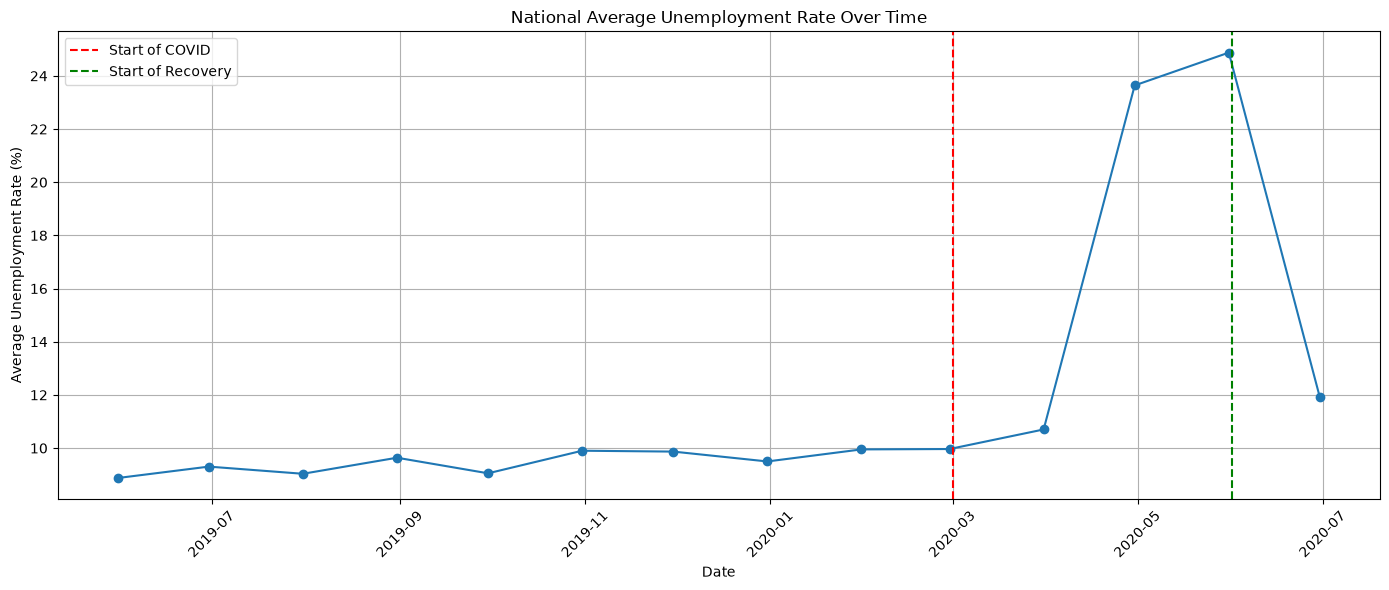

In [30]:
national_avg = (
    df.groupby('Date')['Estimated_Unemployment_Rate_(%)']
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    national_avg.index,
    national_avg.values,
    marker='o'
)

plt.axvline(
    pd.Timestamp('2020-03-01'),
    color='red',
    linestyle='--',
    label='Start of COVID'
)

plt.axvline(
    pd.Timestamp('2020-06-01'),
    color='green',
    linestyle='--',
    label='Start of Recovery'
)

plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('National Average Unemployment Rate Over Time')

plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.savefig('../images/09_national_unemployment_with_marker.png', dpi=150, bbox_inches='tight')
plt.show()

The unemployment rate stayed steady, around 9-10%, from May 2019 all the way to
February 2020. Then it shot up fast once lockdown started in March 2020, hit its
worst point around April, and started coming back down by June. This is a clean,
clear before-during-after shape — not a slow drift, a sharp shock.

In [58]:
conditions = [
    df['Date'] < '2020-03-01',
    (df['Date'] >= '2020-03-01') & (df['Date'] <= '2020-06-01'),
    df['Date'] > '2020-06-01'
]

choices = [
    'Before',
    'During',
    'Recovery'
]

df['Period'] = np.select(conditions, choices, default='Unknown')

print(df[['Date', 'Period']].head(20))
print(f'\n{'='*50}')
print(df['Period'].value_counts())

         Date    Period
0  2019-05-31    Before
1  2019-06-30    Before
2  2019-07-31    Before
3  2019-08-31    Before
4  2019-09-30    Before
5  2019-10-31    Before
6  2019-11-30    Before
7  2019-12-31    Before
8  2020-01-31    Before
9  2020-02-29    Before
10 2020-03-31    During
11 2020-04-30    During
12 2020-05-31    During
13 2020-06-30  Recovery
14 2019-05-31    Before
15 2019-06-30    Before
16 2019-07-31    Before
17 2019-08-31    Before
18 2019-09-30    Before
19 2019-10-31    Before

Period
Before      536
During      154
Recovery     50
Name: count, dtype: int64


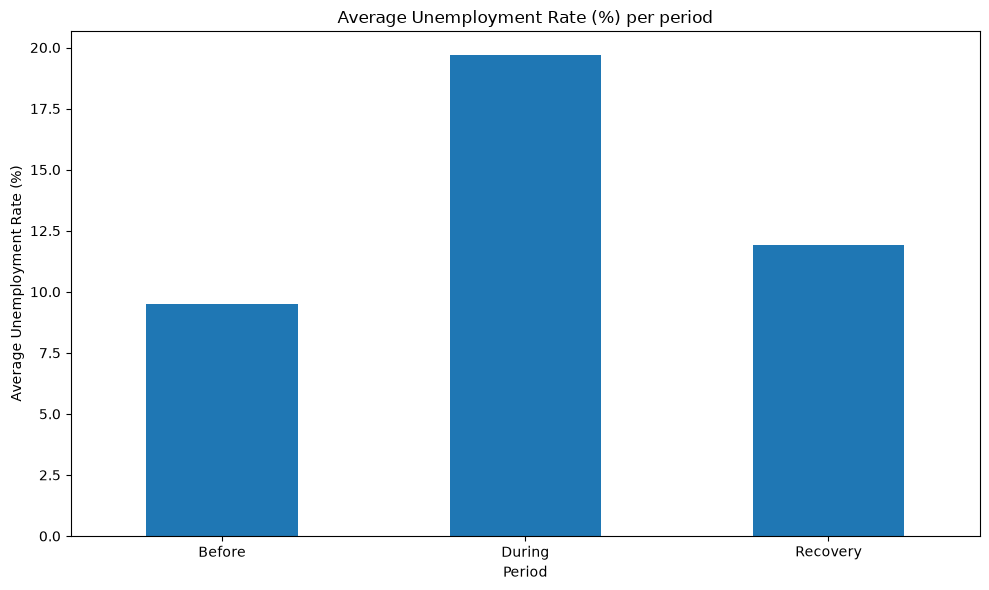

Period
Before       9.509534
During      19.680455
Recovery    11.903600
Name: Estimated_Unemployment_Rate_(%), dtype: float64


In [59]:
avg_rate_period = (
    df.groupby('Period')['Estimated_Unemployment_Rate_(%)']
    .mean()
)

avg_rate_period.plot(kind='bar', figsize=(10, 6))

plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')
plt.title('Average Unemployment Rate (%) per period')

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('../images/10_unemployment_rate_per_period.png', dpi=150, bbox_inches='tight')
plt.show()


print(avg_rate_period)

Putting real numbers on the three periods:

- Before COVID: average rate was 9.5%
- During COVID (March-May 2020): average rate jumped to 19.7% — about double
- Recovery (June 2020 onward): average rate came down to 11.9%, still a bit
  higher than before, but clearly on its way back down

So the shock roughly doubled the national unemployment rate, and by the last
month we have data for, it had not fully returned to normal yet.

In [60]:
before_covid = df[df['Period'] == 'Before']
covid_period = df[df['Period'] == 'During']

# Regional rate before covid
normal_regional_rate = (
    before_covid
    .groupby('Region')['Estimated_Unemployment_Rate_(%)']
    .mean()
)

# Max regional Rate during covid
worst_regional_rate = (
    covid_period
    .groupby('Region')['Estimated_Unemployment_Rate_(%)']
    .max()
)

regional_impact = (
    pd.DataFrame({
        'Normal_rate': normal_regional_rate,
        'Worst_rate': worst_regional_rate,
        'Change': worst_regional_rate - normal_regional_rate,
        'Times_Higher': worst_regional_rate / normal_regional_rate
    })
    .sort_values('Change', ascending=False)
)
regional_impact


,Normal_rate,Worst_rate,Change,Times_Higher
Region,,,,
Puducherry,1.593000,76.74,75.147000,48.173258
Jharkhand,14.279500,70.17,55.890500,4.914038
Tamil Nadu,2.836500,53.19,50.353500,18.751983
Bihar,13.833000,58.77,44.937000,4.248536
Madhya Pradesh,4.741000,40.49,35.749000,8.540392
Telangana,4.656000,36.57,31.914000,7.854381
Delhi,14.230500,45.78,31.549500,3.217034
Himachal Pradesh,19.129000,50.00,30.871000,2.613832
Karnataka,3.234500,33.17,29.935500,10.255063


Some regions were hit much harder than others. The three biggest jumps:

- Puducherry: went from 1.6% to 76.7% — was doing fine, then got hit the hardest of anyone
- Jharkhand: went from 14.3% to 70.2% — already had a rough starting point, then got worse
- Tamil Nadu: went from 2.8% to 53.2% — like Puducherry, a low-unemployment place that suddenly wasn't

Two things worth keeping in mind when reading this table:

1. A region that started very low (like Puducherry) will always show a huge
   "times higher" number, even for a jump that isn't unusual in real terms.
   The plain point-change ("Change" column) is the safer number to trust first.
2. Chandigarh shows the smallest change here, but remember — Chandigarh barely
   has any data at all (see 02_data_cleaning.ipynb). Its low number might just
   mean "we don't have enough information," not "COVID barely touched it."

In [61]:
# Average area rate before covid
normal_area_rate = (
    before_covid
    .groupby('Area')['Estimated_Unemployment_Rate_(%)']
    .mean()
)

# Max area rate during covid
worst_area_rate = (
    covid_period
    .groupby('Area')['Estimated_Unemployment_Rate_(%)']
    .max()
)

area_impact = (
    pd.DataFrame({
        'Normal_rate': normal_area_rate,
        'Worst_rate': worst_area_rate,
        'Change': worst_area_rate - normal_area_rate,
        'Times_Higher': worst_area_rate / normal_area_rate
    })
    .sort_values('Change', ascending=False)
)

area_impact

,Normal_rate,Worst_rate,Change,Times_Higher
Area,,,,
Rural,8.094808,74.51,66.415192,9.204666
Urban,10.842246,76.74,65.897754,7.077869


Rural and Urban areas got hit by almost the exact same real amount — Rural rose
by 66.4 points, Urban by 65.9 points. Basically the same size jump.

But here's the twist: since Rural started from a lower number (8.1% vs Urban's
10.8%), the same jump means Rural's rate multiplied by about 9 times, while
Urban's multiplied by about 7 times. So in plain terms: COVID hit Rural and
Urban by roughly the same raw amount, but it was a bigger relative shock for
Rural areas, since they had less "cushion" to begin with.

## COVID-19 Impact Summary

### What happened, nationally
Unemployment held steady around 9-10% before COVID, spiked to about 19.7%
during lockdown (March-May 2020), and had come back down to 11.9% by June —
still a bit above normal, not fully recovered yet in this data.

### Which regions were hit hardest
Puducherry, Jharkhand, and Tamil Nadu saw the biggest jumps. Puducherry and
Tamil Nadu started from very low unemployment and were hit hardest in relative
terms; Jharkhand was already struggling before COVID and got worse on top of
that. Chandigarh's small numbers should be read carefully — its data is
incomplete, not necessarily a sign it was unaffected.

### Rural vs Urban
Both areas rose by almost the same real amount (~66 points each). But since
Rural started lower, the COVID shock was proportionally bigger there — Rural's
rate multiplied by about 9x, Urban's by about 7x.

### Next step
Seasonal trends — is there a normal up-and-down pattern across months,
separate from the COVID shock, and does it look the same before and after
the pandemic hit?